In [140]:
import sys
sys.path.append("..")

from pneumoviz.data_loader import DataLoader
from pneumoviz.data_processor1 import DataProcessor
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

import plotly.express as px

In [141]:
import plotly.express as px
import pandas as pd

# Exemple de dataframe
df = pd.DataFrame({
    'country': ['France', 'Brazil', 'Japan', 'South Africa', 'Canada'],
    'continent': ['Europe', 'Americas', 'Asia', 'Africa', 'Americas']
})

# Carte Choroplèthe simple
fig = px.choropleth(
    df,
    locations="country",            # Colonne contenant le nom des pays
    locationmode="country names",   # On indique que c'est des noms de pays
    color="continent",              # Ce que tu veux afficher par couleur
    title="Carte des pays par continent",
)

fig.show(renderer="browser")


C:\Users\dell\AppData\Local\Temp\ipykernel_7120\4985398.py:11: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [142]:
downloader = DataLoader()
dfs = downloader.download_all()

df_child_deaths = dfs["child_deaths"]
df_vaccine_coverage = dfs["vaccine_coverage"]
df_ihme_data = dfs["ihme_data"]
df_immunization_schedule = dfs["immunization_schedule"]
df_averted_deaths = dfs["averted_deaths"]
df_careseeking = dfs["careseeking"]
df_final_dose_share = dfs["final_dose_share"]

# df_child_deaths DataFrame

In [143]:
# Example plot using seaborn to visualize child deaths by year for France
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_child_deaths[df_child_deaths['Entity'] == 'France'], x='Year', y='Deaths')
plt.title('Child Deaths by Year in France')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')  
plt.show()

ValueError: Could not interpret value `Deaths` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [ ]:
# clean and process data child deaths
def process_child_deaths(df):
    # drop columns Streptococcus non-pneumonia-non-meningitis deaths (aged under-5) and Streptococcus meningitis deaths (aged under-5)
    df = df.drop(columns=["Streptococcus non-pneumonia-non-meningitis deaths (aged under-5)", "Streptococcus meningitis deaths (aged under-5)"])
    # rename column Streptococcus pneumonia deaths (aged under-5) to Deaths
    df = df.rename(columns={"Streptococcus pneumonia deaths (aged under-5)": "Deaths"})
    # drop wolrd from dataframe
    df_child_deaths = df_child_deaths[df_child_deaths['Entity'] != 'World']
    # map countries to continents
    continent_mapping = {
    # Africa
    'Algeria': 'Africa', 'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cabo Verde': 'Africa',
    "Cote d'Ivoire": 'Africa', 'Cameroon': 'Africa', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Comoros': 'Africa', 'Congo': 'Africa',
    'Democratic Republic of Congo': 'Africa', 'Djibouti': 'Africa',
    'Egypt': 'Africa', 'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa',
    'Eswatini': 'Africa', 'Ethiopia': 'Africa', 'Gabon': 'Africa', 'Gambia': 'Africa',
    'Ghana': 'Africa', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa',
    'Kenya': 'Africa', 'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa',
    'Madagascar': 'Africa', 'Malawi': 'Africa', 'Mali': 'Africa', 'Mauritania': 'Africa',
    'Mauritius': 'Africa', 'Morocco': 'Africa', 'Mozambique': 'Africa',
    'Namibia': 'Africa', 'Niger': 'Africa', 'Nigeria': 'Africa',
    'Rwanda': 'Africa', 'Sao Tome and Principe': 'Africa', 'Senegal': 'Africa',
    'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'South Sudan': 'Africa', 'Sudan': 'Africa',
    'Tanzania': 'Africa', 'Togo': 'Africa', 'Tunisia': 'Africa', 'Uganda': 'Africa',
    'Zambia': 'Africa', 'Zimbabwe': 'Africa',

    # Asia
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bahrain': 'Asia',
    'Bangladesh': 'Asia', 'Bhutan': 'Asia', 'Brunei': 'Asia', 'Cambodia': 'Asia',
    'China': 'Asia', 'Cyprus': 'Asia', 'East Timor': 'Asia', 'Georgia': 'Asia',
    'India': 'Asia', 'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia',
    'Israel': 'Asia', 'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia',
    'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Lebanon': 'Asia',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mongolia': 'Asia', 'Myanmar': 'Asia',
    'Nepal': 'Asia', 'North Korea': 'Asia', 'Oman': 'Asia', 'Pakistan': 'Asia',
    'Philippines': 'Asia', 'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'Singapore': 'Asia',
    'South Korea': 'Asia', 'Sri Lanka': 'Asia', 'Syria': 'Asia',
    'Tajikistan': 'Asia', 'Thailand': 'Asia', 'Turkey': 'Asia', 'Turkmenistan': 'Asia',
    'United Arab Emirates': 'Asia', 'Uzbekistan': 'Asia', 'Vietnam': 'Asia', 'Yemen': 'Asia',

    # Europe
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe',
    'Belgium': 'Europe', 'Bosnia and Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Czechia': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe',
    'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe',
    'Hungary': 'Europe', 'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe',
    'Latvia': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe',
    'Malta': 'Europe', 'Moldova': 'Europe', 'Monaco': 'Europe', 'Montenegro': 'Europe',
    'Netherlands': 'Europe', 'North Macedonia': 'Europe', 'Norway': 'Europe',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe', 'Russia': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe',
    'United Kingdom': 'Europe',

    # North America
    'Antigua and Barbuda': 'North America', 'Bahamas': 'North America',
    'Barbados': 'North America', 'Belize': 'North America', 'Canada': 'North America',
    'Costa Rica': 'North America', 'Cuba': 'North America', 'Dominica': 'North America',
    'Dominican Republic': 'North America', 'El Salvador': 'North America',
    'Grenada': 'North America', 'Guatemala': 'North America', 'Haiti': 'North America',
    'Honduras': 'North America', 'Jamaica': 'North America', 'Mexico': 'North America',
    'Nicaragua': 'North America', 'Panama': 'North America', 'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and the Grenadines': 'North America',
    'Trinidad and Tobago': 'North America', 'United States': 'North America',

    # South America
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America',
    'Chile': 'South America', 'Colombia': 'South America', 'Ecuador': 'South America',
    'Guyana': 'South America', 'Paraguay': 'South America', 'Peru': 'South America',
    'Suriname': 'South America', 'Uruguay': 'South America', 'Venezuela': 'South America',

    # Oceania
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'Kiribati': 'Oceania',
    'Marshall Islands': 'Oceania', 'Micronesia (country)': 'Oceania',
    'Nauru': 'Oceania', 'New Zealand': 'Oceania', 'Palau': 'Oceania',
    'Papua New Guinea': 'Oceania', 'Samoa': 'Oceania', 'Solomon Islands': 'Oceania',
    'Tonga': 'Oceania', 'Tuvalu': 'Oceania', 'Vanuatu': 'Oceania'
    }
    df_child_deaths['Continent'] = df_child_deaths['Entity'].map(continent_mapping)
    
    return df

In [ ]:
# process child deaths data
df_child_deaths = process_child_deaths(df_child_deaths)
df_child_deaths.head()

,Entity,Code,Year,Deaths
0,Afghanistan,AFG,2000,8257
1,Afghanistan,AFG,2001,8415
2,Afghanistan,AFG,2002,8520
3,Afghanistan,AFG,2003,8598
4,Afghanistan,AFG,2004,8603


In [ ]:
# create a map with px to show child deaths by continent in 2019
fig = px.choropleth(df_child_deaths[df_child_deaths['Year'] == 2019],
                    locations="Entity",
                    locationmode='country names',
                    color="Deaths",
                    hover_name="Entity",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Child Deaths by Country in 2019")
fig.show(renderer="browser")

C:\Users\dell\AppData\Local\Temp\ipykernel_7120\4259856835.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [ ]:
# create a map with px to show child deaths by continent in 2019
fig = px.choropleth(df_child_deaths[df_child_deaths['Year'] == 2019],
                    locations=df_child_deaths[df_child_deaths['Year'] == 2019]["Entity"],
                    locationmode=df_child_deaths['Entity'],
                    color="Deaths",
                    hover_name="Entity",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Child Deaths by Country in 2019")
fig.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_7120\2888649231.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
continent_mapping = {
    # Africa
    'Algeria': 'Africa', 'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cabo Verde': 'Africa',
    "Cote d'Ivoire": 'Africa', 'Cameroon': 'Africa', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Comoros': 'Africa', 'Congo': 'Africa',
    'Democratic Republic of Congo': 'Africa', 'Djibouti': 'Africa',
    'Egypt': 'Africa', 'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa',
    'Eswatini': 'Africa', 'Ethiopia': 'Africa', 'Gabon': 'Africa', 'Gambia': 'Africa',
    'Ghana': 'Africa', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa',
    'Kenya': 'Africa', 'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa',
    'Madagascar': 'Africa', 'Malawi': 'Africa', 'Mali': 'Africa', 'Mauritania': 'Africa',
    'Mauritius': 'Africa', 'Morocco': 'Africa', 'Mozambique': 'Africa',
    'Namibia': 'Africa', 'Niger': 'Africa', 'Nigeria': 'Africa',
    'Rwanda': 'Africa', 'Sao Tome and Principe': 'Africa', 'Senegal': 'Africa',
    'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'South Sudan': 'Africa', 'Sudan': 'Africa',
    'Tanzania': 'Africa', 'Togo': 'Africa', 'Tunisia': 'Africa', 'Uganda': 'Africa',
    'Zambia': 'Africa', 'Zimbabwe': 'Africa',

    # Asia
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bahrain': 'Asia',
    'Bangladesh': 'Asia', 'Bhutan': 'Asia', 'Brunei': 'Asia', 'Cambodia': 'Asia',
    'China': 'Asia', 'Cyprus': 'Asia', 'East Timor': 'Asia', 'Georgia': 'Asia',
    'India': 'Asia', 'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia',
    'Israel': 'Asia', 'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia',
    'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Lebanon': 'Asia',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mongolia': 'Asia', 'Myanmar': 'Asia',
    'Nepal': 'Asia', 'North Korea': 'Asia', 'Oman': 'Asia', 'Pakistan': 'Asia',
    'Philippines': 'Asia', 'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'Singapore': 'Asia',
    'South Korea': 'Asia', 'Sri Lanka': 'Asia', 'Syria': 'Asia',
    'Tajikistan': 'Asia', 'Thailand': 'Asia', 'Turkey': 'Asia', 'Turkmenistan': 'Asia',
    'United Arab Emirates': 'Asia', 'Uzbekistan': 'Asia', 'Vietnam': 'Asia', 'Yemen': 'Asia',

    # Europe
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe',
    'Belgium': 'Europe', 'Bosnia and Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Czechia': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe',
    'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe',
    'Hungary': 'Europe', 'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe',
    'Latvia': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe',
    'Malta': 'Europe', 'Moldova': 'Europe', 'Monaco': 'Europe', 'Montenegro': 'Europe',
    'Netherlands': 'Europe', 'North Macedonia': 'Europe', 'Norway': 'Europe',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe', 'Russia': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe',
    'United Kingdom': 'Europe',

    # North America
    'Antigua and Barbuda': 'North America', 'Bahamas': 'North America',
    'Barbados': 'North America', 'Belize': 'North America', 'Canada': 'North America',
    'Costa Rica': 'North America', 'Cuba': 'North America', 'Dominica': 'North America',
    'Dominican Republic': 'North America', 'El Salvador': 'North America',
    'Grenada': 'North America', 'Guatemala': 'North America', 'Haiti': 'North America',
    'Honduras': 'North America', 'Jamaica': 'North America', 'Mexico': 'North America',
    'Nicaragua': 'North America', 'Panama': 'North America', 'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and the Grenadines': 'North America',
    'Trinidad and Tobago': 'North America', 'United States': 'North America',

    # South America
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America',
    'Chile': 'South America', 'Colombia': 'South America', 'Ecuador': 'South America',
    'Guyana': 'South America', 'Paraguay': 'South America', 'Peru': 'South America',
    'Suriname': 'South America', 'Uruguay': 'South America', 'Venezuela': 'South America',

    # Oceania
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'Kiribati': 'Oceania',
    'Marshall Islands': 'Oceania', 'Micronesia (country)': 'Oceania',
    'Nauru': 'Oceania', 'New Zealand': 'Oceania', 'Palau': 'Oceania',
    'Papua New Guinea': 'Oceania', 'Samoa': 'Oceania', 'Solomon Islands': 'Oceania',
    'Tonga': 'Oceania', 'Tuvalu': 'Oceania', 'Vanuatu': 'Oceania',

    # Special Case
    'World': 'World'
}
df_child_deaths['Continent'] = df_child_deaths['Entity'].map(continent_mapping)
# drop wolrd from dataframe
df_child_deaths = df_child_deaths[df_child_deaths['Entity'] != 'World']

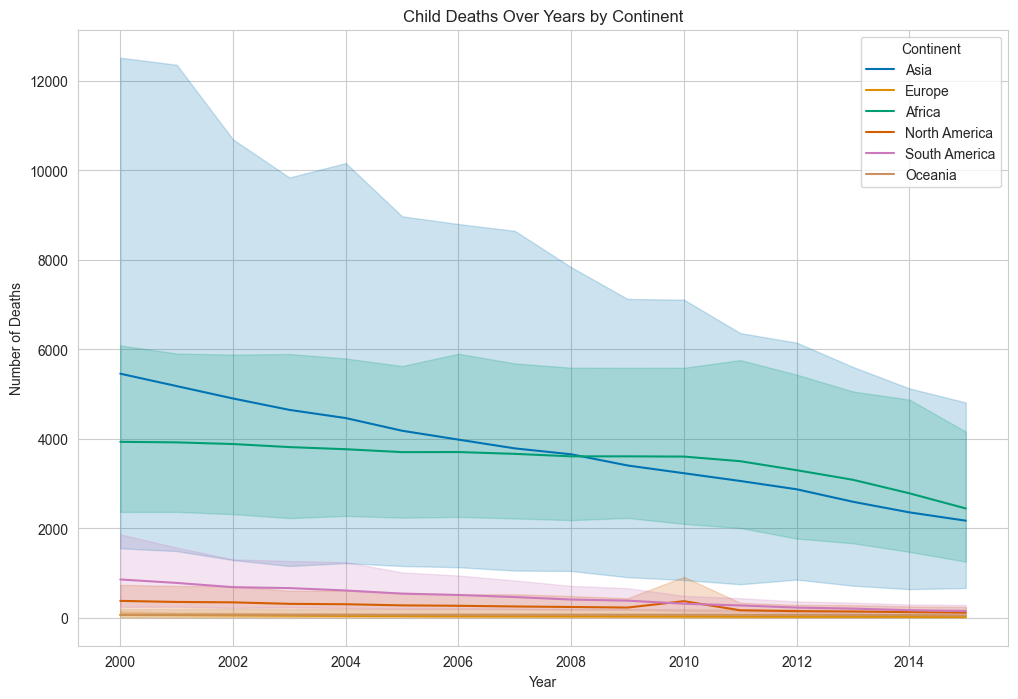

In [ ]:
# Example plot Continents 
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_child_deaths, x="Year", y="Deaths", hue="Continent")
plt.title("Child Deaths Over Years by Continent")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.legend(title="Continent")
plt.show()

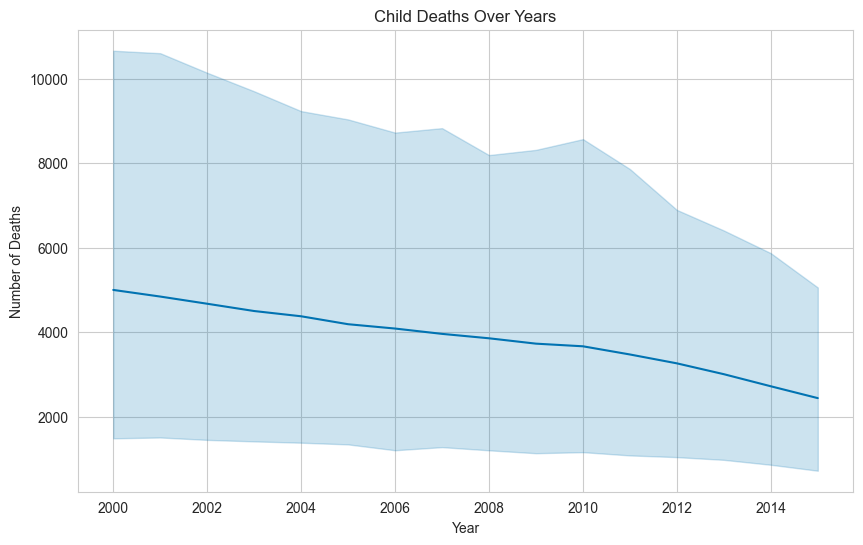

In [ ]:
# Example plot using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_child_deaths, x="Year", y="Deaths")
plt.title("Child Deaths Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.show()

In [ ]:
print(df_child_deaths["Entity"].unique()[99:])

['Lithuania' 'Luxembourg' 'Madagascar' 'Malawi' 'Malaysia' 'Maldives'
 'Mali' 'Malta' 'Marshall Islands' 'Mauritania' 'Mauritius' 'Mexico'
 'Micronesia (country)' 'Moldova' 'Monaco' 'Mongolia' 'Montenegro'
 'Morocco' 'Mozambique' 'Myanmar' 'Namibia' 'Nauru' 'Nepal' 'Netherlands'
 'New Zealand' 'Nicaragua' 'Niger' 'Nigeria' 'Niue' 'North Korea'
 'North Macedonia' 'Norway' 'Oman' 'Pakistan' 'Palau' 'Panama'
 'Papua New Guinea' 'Paraguay' 'Peru' 'Philippines' 'Poland' 'Portugal'
 'Qatar' 'Romania' 'Russia' 'Rwanda' 'Saint Kitts and Nevis' 'Saint Lucia'
 'Saint Vincent and the Grenadines' 'Samoa' 'San Marino'
 'Sao Tome and Principe' 'Saudi Arabia' 'Senegal' 'Serbia' 'Seychelles'
 'Sierra Leone' 'Singapore' 'Slovakia' 'Slovenia' 'Solomon Islands'
 'Somalia' 'South Africa' 'South Korea' 'South Sudan' 'Spain' 'Sri Lanka'
 'Sudan' 'Suriname' 'Sweden' 'Switzerland' 'Syria' 'Tajikistan' 'Tanzania'
 'Thailand' 'Togo' 'Tonga' 'Trinidad and Tobago' 'Tunisia' 'Turkey'
 'Turkmenistan' 'Tuvalu' 'Ugan

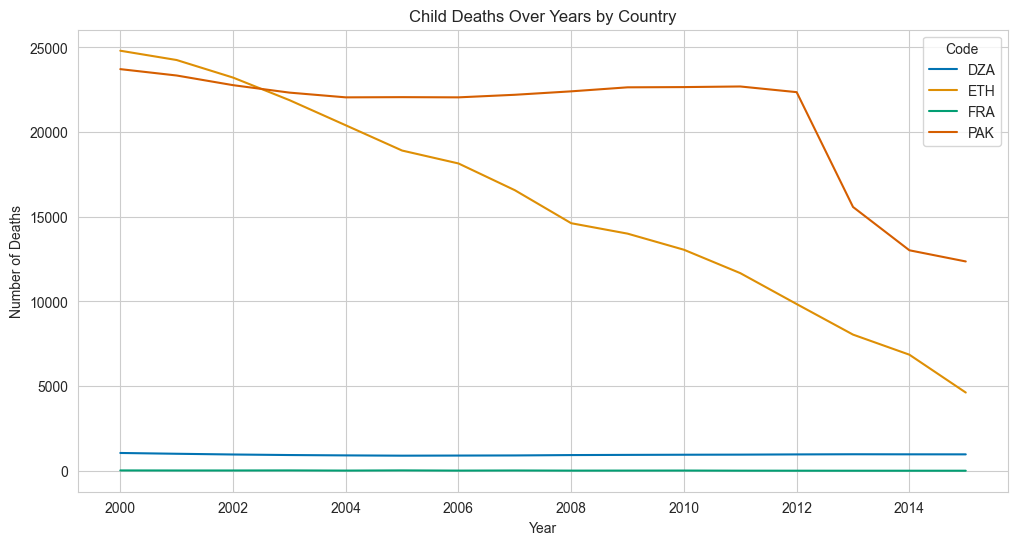

In [ ]:
# selected countries for visualization
selected_countries = ["France", "Algeria", "Pakistan", "Ethiopia", "Democratic Republic of the Congo"]
# Example plot using seaborn
sns.lineplot(data=df_child_deaths[df_child_deaths["Entity"].isin(selected_countries)], x="Year", y="Deaths", hue="Code")
plt.title("Child Deaths Over Years by Country")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.show()

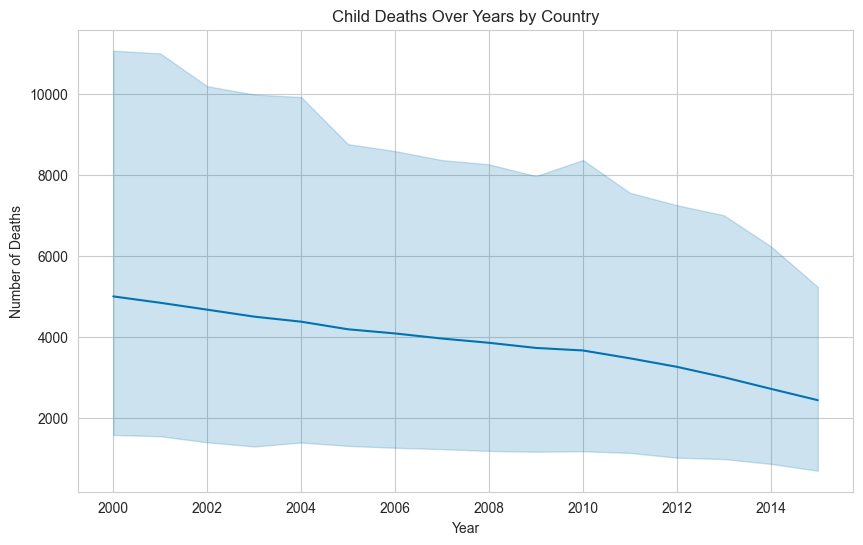

In [ ]:
# Example plot using seaborn
plt.figure(figsize=(10, 6)) 
sns.lineplot(data=df_child_deaths, x="Year", y="Deaths")
plt.title("Child Deaths Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.show()

In [ ]:
df_child_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 6 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   Entity                                                            3120 non-null   object
 1   Code                                                              3120 non-null   object
 2   Year                                                              3120 non-null   int64 
 3   Streptococcus non-pneumonia-non-meningitis deaths (aged under-5)  3120 non-null   int64 
 4   Streptococcus meningitis deaths (aged under-5)                    3120 non-null   int64 
 5   Streptococcus pneumonia deaths (aged under-5)                     3120 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 146.4+ KB


In [ ]:
# Example plot using seaborn
sns.lineplot(data=df_child_deaths, x="Year", y="Deaths", hue="Country")
plt.title("Child Deaths Over Years by Country")
plt.xlabel("Year") 
plt.ylabel("Number of Deaths")
plt.show()

ValueError: Could not interpret value `Deaths` for `y`. An entry with this name does not appear in `data`.

In [ ]:
df_child_deaths.Entity.unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia',
       'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Grenada', 'Guatemala', 'Guine

In [ ]:
df_child_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 6 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   Entity                                                            3120 non-null   object
 1   Code                                                              3120 non-null   object
 2   Year                                                              3120 non-null   int64 
 3   Streptococcus non-pneumonia-non-meningitis deaths (aged under-5)  3120 non-null   int64 
 4   Streptococcus meningitis deaths (aged under-5)                    3120 non-null   int64 
 5   Streptococcus pneumonia deaths (aged under-5)                     3120 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 146.4+ KB


In [ ]:
df_child_deaths.describe()

,Year,Streptococcus non-pneumonia-non-meningitis deaths (aged under-5),Streptococcus meningitis deaths (aged under-5),Streptococcus pneumonia deaths (aged under-5)
count,3120.000000,3120.000000,3120.000000,3120.000000
mean,2007.500000,297.764103,609.801282,3860.450000
std,4.610511,2168.237680,4490.402475,28370.841447
min,2000.000000,0.000000,0.000000,0.000000
25%,2003.750000,1.000000,1.000000,5.000000
50%,2007.500000,11.000000,14.000000,88.000000
75%,2011.250000,102.000000,157.000000,1026.750000
max,2015.000000,33261.000000,79231.000000,487536.000000


In [ ]:
df = df_child_deaths.

df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['entity', 'code', 'year',
       'streptococcus_non-pneumonia-non-meningitis_deaths_(aged_under-5)',
       'streptococcus_meningitis_deaths_(aged_under-5)',
       'streptococcus_pneumonia_deaths_(aged_under-5)'],
      dtype='object')

In [ ]:
import numpy as np
# Ensure numeric columns are properly typed
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Filter out aggregated regions if 'code' column exists
if 'code' in df.columns:
    df = df[df['code'].notna()]

# df_vaccine_coverage DataFrame

In [ ]:
df_vaccine_coverage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9252 entries, 0 to 9251
Data columns (total 6 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   Entity                                                                                            9252 non-null   object 
 1   Code                                                                                              8208 non-null   object 
 2   Year                                                                                              9252 non-null   int64  
 3   Share of one-year-olds who have had the third dose of the pneumococcal conjugate vaccine          2260 non-null   float64
 4   Share of one-year-olds who have had three doses of the diphtheria, tetanus and pertussis vaccine  9174 non-null   float64
 5   

In [ ]:
df_vaccine_coverage.head()

,Entity,Code,Year,Share of one-year-olds who have had the third dose of the pneumococcal conjugate vaccine,"Share of one-year-olds who have had three doses of the diphtheria, tetanus and pertussis vaccine",World regions according to OWID
0,Afghanistan,AFG,2014,49.0,62.0,NaN
1,Afghanistan,AFG,2015,64.0,64.0,NaN
2,Afghanistan,AFG,2016,62.0,66.0,NaN
3,Afghanistan,AFG,2017,63.0,64.0,NaN
4,Afghanistan,AFG,2018,64.0,68.0,NaN


In [ ]:
# clean and process data vaccine coverage
def process_vaccine_coverage(df):
    # rename column Share of one-year-olds who have had the third dose of the pneumococcal conjugate vaccine to Vaccine_Coverage
    df = df.rename(columns={"Share of one-year-olds who have had the third dose of the pneumococcal conjugate vaccine": "Vaccine_Coverage"})
    # drop rows with NaN values in Vaccine_Coverage column
    df = df.dropna(subset=["Vaccine_Coverage"])
    # drop h columns not needed
    df = df.drop(columns=["World regions according to OWID", "Share of one-year-olds who have had three doses of the diphtheria, tetanus and pertussis vaccine"])
    return df

In [ ]:
df_vaccine_coverage = process_vaccine_coverage(df_vaccine_coverage)
df_vaccine_coverage.head()

,Entity,Code,Year,Vaccine_Coverage
0,Afghanistan,AFG,2014,49.0
1,Afghanistan,AFG,2015,64.0
2,Afghanistan,AFG,2016,62.0
3,Afghanistan,AFG,2017,63.0
4,Afghanistan,AFG,2018,64.0


In [ ]:
df_vaccine_coverage.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260 entries, 0 to 9220
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Entity            2260 non-null   object 
 1   Code              1877 non-null   object 
 2   Year              2260 non-null   int64  
 3   Vaccine_Coverage  2260 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 88.3+ KB


In [ ]:
# show dataframe when code nan 
df_nan_code = df_vaccine_coverage[df_vaccine_coverage['Code'].isna()]

In [ ]:
df_nan_code["Entity"].unique()

array(['Africa', 'Africa (WHO)', 'Americas (WHO)', 'Asia',
       'East Asia and the Pacific (UNICEF)',
       'Eastern Mediterranean (WHO)',
       'Eastern and Southern Africa (UNICEF)', 'Europe', 'Europe (WHO)',
       'High-income countries',
       'Latin America and the Caribbean (UNICEF)', 'Low-income countries',
       'Lower-middle-income countries',
       'Middle East and North Africa (UNICEF)', 'Middle-income countries',
       'North America', 'Oceania', 'South America', 'South Asia (UNICEF)',
       'South-East Asia (WHO)', 'Upper-middle-income countries',
       'West and Central Africa (UNICEF)', 'Western Pacific (WHO)'],
      dtype=object)

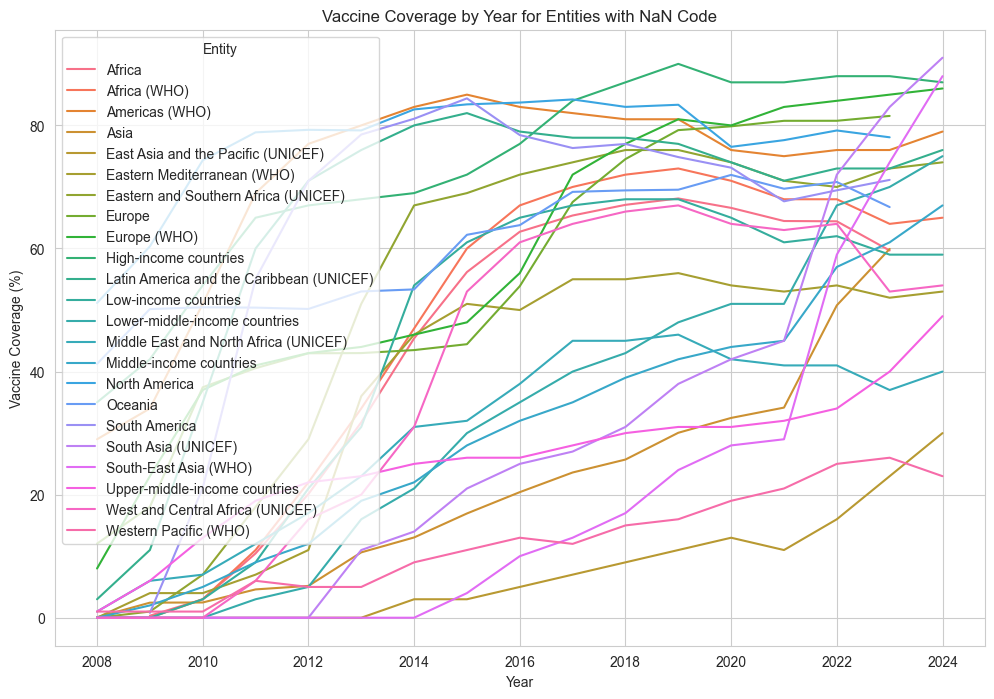

In [ ]:
# Example plot using seaborn to visualize vaccine coverage by Entity in df_nan_code
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_nan_code, x='Year', y='Vaccine_Coverage', hue='Entity')
plt.title('Vaccine Coverage by Year for Entities with NaN Code')
plt.xlabel('Year')
plt.ylabel('Vaccine Coverage (%)')
plt.legend(title='Entity')
plt.show()

# df_ihme_data DataFrame

In [144]:
df_ihme_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5184 entries, 0 to 5183
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   measure_id     5184 non-null   int64  
 1   measure_name   5184 non-null   object 
 2   location_id    5184 non-null   int64  
 3   location_name  5184 non-null   object 
 4   sex_id         5184 non-null   int64  
 5   sex_name       5184 non-null   object 
 6   age_id         5184 non-null   int64  
 7   age_name       5184 non-null   object 
 8   cause_id       5184 non-null   int64  
 9   cause_name     5184 non-null   object 
 10  metric_id      5184 non-null   int64  
 11  metric_name    5184 non-null   object 
 12  year           5184 non-null   int64  
 13  val            5184 non-null   float64
 14  upper          5184 non-null   float64
 15  lower          5184 non-null   float64
dtypes: float64(3), int64(7), object(6)
memory usage: 648.1+ KB


In [145]:
df_ihme_data["location_name"].unique()

array(['G20', 'African Union', 'World Bank Income Levels',
       'Organization of Islamic Cooperation', 'Global',
       'World Bank Regions', 'Commonwealth', 'Gulf Cooperation Council',
       'Polynesia', 'European Union', 'Melanesia',
       'League of Arab States', 'Micronesia', 'OECD Countries',
       'Sahel Region', 'Nordic Region'], dtype=object)

In [146]:
# clean and process data ihme_data
def process_ihme_data(df):
    # drop columns not needed
    df = df.drop(columns=["measure_id", "metric_id", "cause_id", "age_group_id", "sex_id","sex_name", "val", "location_name", "location_id", "upper", "lower"])
    return df

In [147]:
df_ihme_data.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,Décès,44586,G20,1,Homme,8,15-19 ans,510,Pneumoconiose,1,#,2023,3.841552,6.424419,2.172465
1,1,Décès,44586,G20,2,Femme,8,15-19 ans,510,Pneumoconiose,1,#,2023,2.295758,4.308122,1.193011
2,1,Décès,44586,G20,3,Les deux,8,15-19 ans,510,Pneumoconiose,1,#,2023,6.137309,9.476764,4.017610
3,1,Décès,44586,G20,1,Homme,8,15-19 ans,510,Pneumoconiose,2,%,2023,0.000031,0.000051,0.000017
4,1,Décès,44586,G20,2,Femme,8,15-19 ans,510,Pneumoconiose,2,%,2023,0.000028,0.000051,0.000014


In [148]:
df_ihme_data["age_name"].unique()
df_ihme_data["age_name"].value_counts()

age_name
15-19 ans         144
20-24 ans         144
25-29 ans         144
30-34 ans         144
                 ... 
95 ans et plus    144
75-84 ans         144
20-54 ans         144
<70 ans           144
Name: count, Length: 36, dtype: int64

In [149]:
import plotly.express as px

fig = px.histogram(
    df_ihme_data,
    x="sex_name",
    color="sex_name",
    title="Nombre d'observations par sexe (2023)",
    labels={"sex_name": "Sexe", "count": "Nombre d'entrées"},
)

#show figure in browser 
fig.show(renderer="browser")


C:\Users\dell\AppData\Local\Temp\ipykernel_7120\1922114394.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




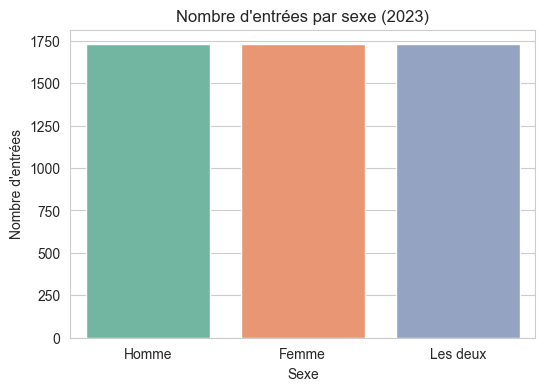

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compter le nombre d'entrées par sexe
plt.figure(figsize=(6,4))
sns.countplot(data=df_ihme_data, x="sex_name", palette="Set2")
plt.title("Nombre d'entrées par sexe (2023)")
plt.xlabel("Sexe")
plt.ylabel("Nombre d'entrées")
plt.show()

# df_immunization_schedule DataFrame

In [151]:
df_immunization_schedule.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 4 columns):
 #   Column                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                    --------------  ----- 
 0   Entity                                                                                                    4831 non-null   object
 1   Code                                                                                                      4831 non-null   object
 2   Year                                                                                                      4831 non-null   int64 
 3   Which countries include the pneumococcal conjugate vaccine (PCV) in their national vaccination programs?  4831 non-null   object
dtypes: int64(1), object(3)
memory usage: 151.1+ KB


# df_averted_deaths DataFrame

In [152]:
df_averted_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Entity          7 non-null      object
 1   Code            1 non-null      object
 2   Year            7 non-null      int64 
 3   Deaths averted  7 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 356.0+ bytes


In [153]:
df_averted_deaths

,Entity,Code,Year,Deaths averted
0,Africa,NaN,2019,275000
1,Asia,NaN,2019,92300
2,Europe,NaN,2019,4860
3,Latin America and the Caribbean,NaN,2019,10800
4,North America,NaN,2019,7540
5,Oceania,NaN,2019,611
6,World,OWID_WRL,2019,399000


In [154]:
def process_averted_deaths(df):
    # drop columns not needed
    df = df.drop(columns=["Code"])
    # drop row of wolrd
    df = df[df['Entity'] != 'World']
    return df

In [155]:
df_averted_deaths = process_averted_deaths(df_averted_deaths)
df_averted_deaths

,Entity,Year,Deaths averted
0,Africa,2019,275000
1,Asia,2019,92300
2,Europe,2019,4860
3,Latin America and the Caribbean,2019,10800
4,North America,2019,7540
5,Oceania,2019,611


# df_careseeking DataFrame

In [156]:
df_careseeking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 4 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   Entity                                                                                            272 non-null    object 
 1   Code                                                                                              272 non-null    object 
 2   Year                                                                                              272 non-null    int64  
 3   Children aged < 5 years with pneumonia symptoms taken to a health facility (%) - Sex: both sexes  272 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 8.6+ KB


In [157]:
df_careseeking.head()

,Entity,Code,Year,Children aged < 5 years with pneumonia symptoms taken to a health facility (%) - Sex: both sexes
0,Afghanistan,AFG,2010,60.397076
1,Afghanistan,AFG,2015,61.330600
2,Albania,ALB,2005,46.503680
3,Albania,ALB,2008,70.029830
4,Albania,ALB,2017,81.912660


In [158]:
df_careseeking

,Entity,Code,Year,Children aged < 5 years with pneumonia symptoms taken to a health facility (%) - Sex: both sexes
0,Afghanistan,AFG,2010,60.397076
1,Afghanistan,AFG,2015,61.330600
2,Albania,ALB,2005,46.503680
3,Albania,ALB,2008,70.029830
...,...,...,...,...
268,Zimbabwe,ZWE,2010,48.117058
269,Zimbabwe,ZWE,2014,58.639877
270,Zimbabwe,ZWE,2015,51.313170
271,Zimbabwe,ZWE,2019,43.016495


# df_final_dose_share DataFrame

In [159]:
df_final_dose_share.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260 entries, 0 to 2259
Data columns (total 4 columns):
 #   Column                                                                                    Non-Null Count  Dtype  
---  ------                                                                                    --------------  -----  
 0   Entity                                                                                    2260 non-null   object 
 1   Code                                                                                      1877 non-null   object 
 2   Year                                                                                      2260 non-null   int64  
 3   Share of one-year-olds who have had the third dose of the pneumococcal conjugate vaccine  2260 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 70.8+ KB
